# TEXT MODEL

In this file, readind the output data from feature_engineering.ipynb, we will:

1. Define the PanelSplit
2. Define the model
3. Apply cross_val_fit_predict to do the prediction 
4. Evaluation

In [20]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from panelsplit.cross_validation import PanelSplit
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report, f1_score, roc_auc_score, 
    roc_curve, auc, precision_recall_curve, average_precision_score
)

First we load the data:

In [21]:
df = pd.read_csv("../data_clean/final_text_data.csv")
df = df.set_index(["iso3", "month"])

### DEFINE THE TARGET VARIABLE AND THE FEATURES

In [22]:
def prepare_ml_experiment(df, features_to_use=None, target_col='conflict_2m', extra_drop=[]):
    df_temp = df.copy()
    
    # 1. HIDE THE FUTURE (Mask last 2 months per country)
    # Using cumcount(ascending=False) ensures we find the most recent records per iso3
    last_2_months_mask = df_temp.groupby('iso3').cumcount(ascending=False) < 2
    df_temp[target_col] = df_temp[target_col].astype(float)
    df_temp.loc[last_2_months_mask, target_col] = np.nan

    # 2. FEATURE SELECTION
    if features_to_use is None:
        # Default Blacklist (columns that are text, original categories, or leak info)
        blacklist = [
            target_col, 'sub_event_type', 'disorder_type', 'interaction', 
            'event_type', 'hdx_alert_level', 'notes', 'notes_vector'
        ] + extra_drop
        features_cols = [col for col in df_temp.columns if col not in blacklist]
    else:
        # Use only the provided list
        features_cols = features_to_use

    # 3. CLEANING
    # Ensure we only keep rows where both features and target exist
    df_model = df_temp[features_cols + [target_col]].dropna()
    
    X = df_model[features_cols]
    y = df_model[target_col]
    
    return X, y

['monthly_displacement', 'fatalities', 'population_5km', 'events',  'hdx_value', 'risk', 'logfat_risk', 'any_violence_risk', 'rolling_3m_displacements', 'conflict', 'risk_gt_06', 'is_protracted', 'disp_6m_avg', 'fat_6m_avg', 'hdx_med_high_count', 'hdx_3m_sum', 'p_sig1', 'p_sig2', 'p_sig3', 'protracted_signal', 'h_sig1', 'h_sig2', 'hard_onset_signal', 'early_signal', 'monthly_displacement_lag1', 'monthly_displacement_lag2', 'fatalities_lag1', 'events_lag1', 'risk_lag1', 'hdx_alert_score', 'is_civilian_targeted', 'is_heavy_warfare', 'is_territorial_shift', 'is_social_unrest', 'state_involved', 'state_vs_civilians', 'rebel_involved', 'militia_involved', 'external_forces_involved', 'protesters_only_interaction', 'notes_vector']

Now we are going to define different groups of features and check with which combination the model performs better:

In [23]:
# Only signal features BASELINE
features_signals = ['is_protracted', 'p_sig1', 'p_sig2', 'p_sig3', 'protracted_signal', 'h_sig1', 'h_sig2', 'hard_onset_signal', 
                    'early_signal', 'monthly_displacement', 'fatalities', 'events', 'hdx_value', 'risk','rolling_3m_displacements',
                    'risk_gt_06','disp_6m_avg', 'fat_6m_avg','hdx_3m_sum',]

# Only features historical and statistical features (No signals nor textual features)
features_historical = ['population_5km', 'logfat_risk', 'any_violence_risk', 'monthly_displacement_lag1', 'fatalities_lag1', 
    'conflict', 'hdx_med_high_count', 'monthly_displacement_lag2','events_lag1','risk_lag1','hdx_alert_score','is_civilian_targeted', 
    'is_heavy_warfare', 'is_territorial_shift', 'is_social_unrest', 'state_involved', 'state_vs_civilians', 'rebel_involved', 
    'militia_involved', 'external_forces_involved', 'protesters_only_interaction'
]


# Only features coming from embeddings 
features_emb = [col for col in df.columns if col.startswith('emb_')]

# Only features coming from embeddings mean
features_emb_mean = [col for col in df.columns if col.startswith('emb_mean_')]

# Only features coming from pca
features_pca = [col for col in df.columns if col.startswith('pca_')]

# Only features coming from pca_mean
features_pca_mean = [col for col in df.columns if col.startswith('pca_mean_')]

# Only features from Google Trends
features_google = ['Flight', 'Airport', 'Travel', 'Train', 'Bus', 'Passport', 'Travel_visa', 
                   'Right_of_asylum', 'Flight_lag_1m', 'Airport_lag_1m', 'Travel_lag_1m', 'Train_lag_1m', 'Bus_lag_1m', 
                   'Passport_lag_1m', 'Travel_visa_lag_1m', 'Right_of_asylum_lag_1m', 'Flight_lag_2m', 'Airport_lag_2m', 
                   'Travel_lag_2m', 'Train_lag_2m', 'Bus_lag_2m', 'Passport_lag_2m', 'Travel_visa_lag_2m', 'Right_of_asylum_lag_2m', 
                   'Flight_lag_3m', 'Airport_lag_3m', 'Travel_lag_3m', 'Train_lag_3m', 'Bus_lag_3m', 'Passport_lag_3m', 
                   'Travel_visa_lag_3m', 'Right_of_asylum_lag_3m', 'Flight_growth_1m', 'Airport_growth_1m', 'Travel_growth_1m', 
                   'Train_growth_1m', 'Bus_growth_1m', 'Passport_growth_1m', 'Travel_visa_growth_1m', 'Right_of_asylum_growth_1m', 
                   'Flight_rolling_mean_3m', 'Airport_rolling_mean_3m', 'Travel_rolling_mean_3m', 'Train_rolling_mean_3m', 
                   'Bus_rolling_mean_3m', 'Passport_rolling_mean_3m', 'Travel_visa_rolling_mean_3m', 'Right_of_asylum_rolling_mean_3m']

# Only features from INFORM Index
features_inform = ['INFORM', 'VU', 'CC', 'HA']


In [24]:
# FEATURE SELECTION FUNCTION (Not using the last 2 years of data that will be used as the test set)
def get_valuable_features_safe(df, feature_list, target_col='conflict_2m', top_n=15):
 
    if len(feature_list) <= 3:
        return feature_list
        
    X, y = prepare_ml_experiment(df, features_to_use=feature_list, target_col=target_col)
    
    # Not using the last 2 years of data for feature selection to avoid data leakage
    time_axis = pd.to_datetime(X.index.get_level_values('month'))
    max_date = time_axis.max()
    cutoff_date = max_date - pd.DateOffset(years=2)
    
    # Select only the data before the cutoff date for training the feature selector
    past_mask = time_axis < cutoff_date
    X_train_safe = X[past_mask]
    y_train_safe = y[past_mask]
    
    # Train a Random Forest Classifier to get feature importances
    selector_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    selector_rf.fit(X_train_safe, y_train_safe)
    
    importances = pd.Series(selector_rf.feature_importances_, index=X.columns)
    best_features = importances.sort_values(ascending=False).head(top_n).index.tolist()
    
    return best_features

In [25]:
# FEATURE SELECTION PIPELINE 
best_historical = get_valuable_features_safe(df, features_historical, top_n=15)
best_emb = get_valuable_features_safe(df, features_emb, top_n=10)
best_emb_mean = get_valuable_features_safe(df, features_emb_mean, top_n=8)
best_pca = get_valuable_features_safe(df, features_pca, top_n=8)
best_pca_mean = get_valuable_features_safe(df, features_pca_mean, top_n=3)
best_google = get_valuable_features_safe(df, features_google, top_n=15)
best_inform = get_valuable_features_safe(df, features_inform, top_n=3)

print(f"-> Historical optimized: Keeping {len(best_historical)} / {len(features_historical)}")
print(f"-> Embeddings optimized: Keeping {len(best_emb)} / {len(features_emb)}")
print(f"-> Mean Embeddings optimized: Keeping {len(best_emb_mean)} / {len(features_emb_mean)}")
print(f"-> PCA optimized: Keeping {len(best_pca)} / {len(features_pca)}")
print(f"-> PCA Mean optimized: Keeping {len(best_pca_mean)} / {len(features_pca_mean)}")
print(f"-> Google Trends optimized: Keeping {len(best_google)} / {len(features_google)}")
print(f"-> INFORM Index optimized: Keeping {len(best_inform)} / {len(features_inform)}")


-> Historical optimized: Keeping 15 / 21
-> Embeddings optimized: Keeping 10 / 768
-> Mean Embeddings optimized: Keeping 8 / 384
-> PCA optimized: Keeping 8 / 10
-> PCA Mean optimized: Keeping 3 / 5
-> Google Trends optimized: Keeping 15 / 48
-> INFORM Index optimized: Keeping 3 / 4



RUNNING EXPERIMENT: Baseline (Signals)
Features count: 19

--- TOP 10 PREDICTORS (Baseline (Signals)) ---
disp_6m_avg                 0.215062
rolling_3m_displacements    0.164006
risk                        0.139029
monthly_displacement        0.105535
fat_6m_avg                  0.088044
events                      0.058329
fatalities                  0.049440
risk_gt_06                  0.045723
is_protracted               0.038421
p_sig2                      0.024723
dtype: float64

Classification Report (Baseline (Signals)):
              precision    recall  f1-score   support

         0.0       0.97      0.96      0.97      1994
         1.0       0.21      0.27      0.24        70

    accuracy                           0.94      2064
   macro avg       0.59      0.62      0.60      2064
weighted avg       0.95      0.94      0.94      2064


RUNNING EXPERIMENT: Only Historical
Features count: 15

--- TOP 10 PREDICTORS (Only Historical) ---
logfat_risk                  0.2099

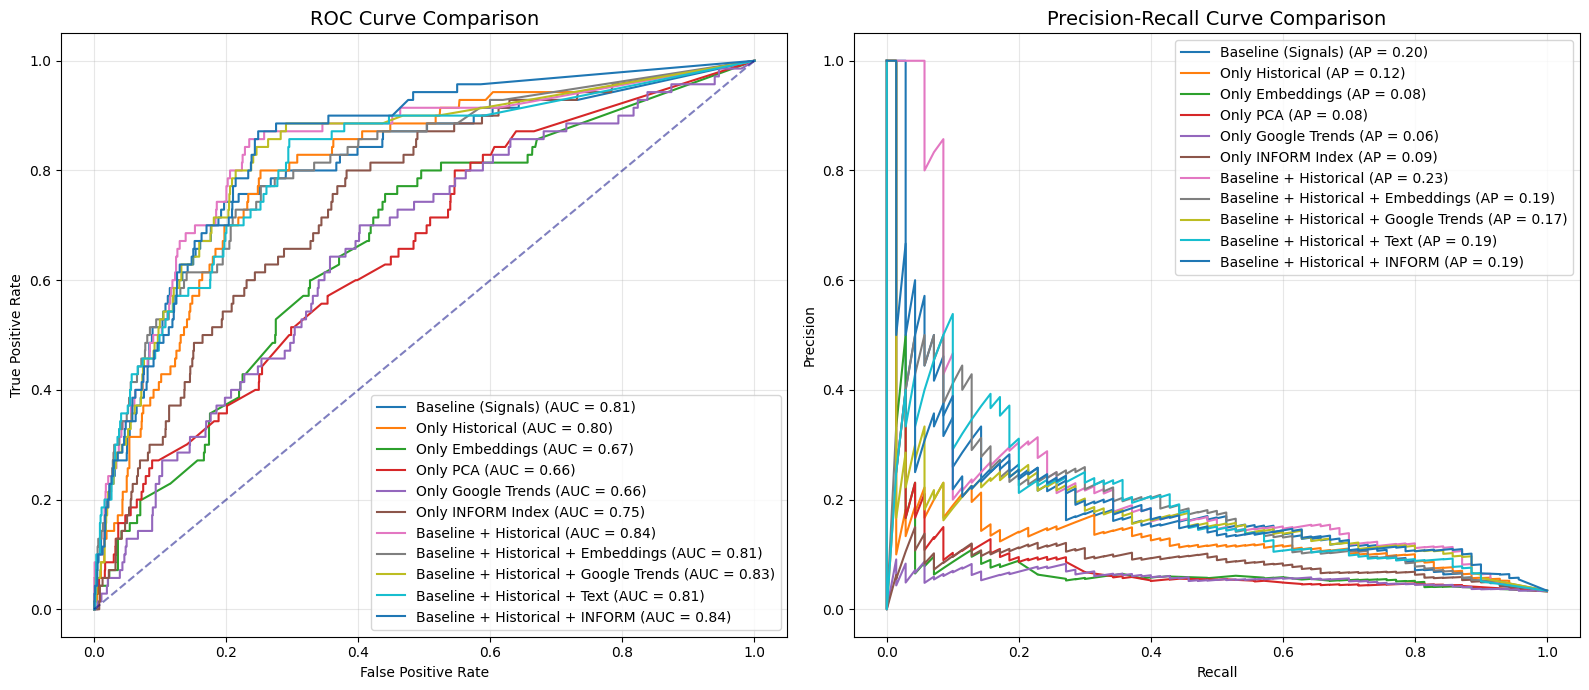

In [17]:
# 1. DEFINE EXPERIMENT SETS
experiments = {
    # --- SOLO GROUPS ---
    "Baseline (Signals)": features_signals,
    "Only Historical": best_historical,
    "Only Embeddings": best_emb + best_emb_mean,
    "Only PCA": best_pca + best_pca_mean, 
    "Only Google Trends": best_google,
    "Only INFORM Index": best_inform,
    
    # --- COMBINED GROUPS ---
    "Baseline + Historical": best_historical + features_signals,
    "Baseline + Historical + Embeddings": best_historical + features_signals + best_emb + best_emb_mean + best_pca + best_pca_mean,
    "Baseline + Historical + Google Trends": best_historical + features_signals + best_google,
    "Baseline + Historical + Text": best_historical + features_signals + best_emb + best_emb_mean + best_pca + best_pca_mean + best_google,
    "Baseline + Historical + INFORM": best_historical + features_signals + best_inform
}

# Containers for results
comparison_results = []

# Prepare the plot layout
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(16, 7))

for name, f_list in experiments.items():
    print(f"\n" + "="*60)
    print(f"RUNNING EXPERIMENT: {name}")
    print(f"Features count: {len(f_list)}")
    print("="*60)
    
    # 2. PREPARE DATA
    X, y = prepare_ml_experiment(df, features_to_use=f_list)
    periods = X.index.get_level_values('month')

    # 3. DEFINE SPLIT STRATEGY
    panel_split = PanelSplit(
        periods=periods,
        n_splits=24,   
        test_size=1,
        gap=1          
    )

    # 4. INITIALIZE MODEL
    rf_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    all_y_true, all_y_pred, all_y_prob = [], [], []

    # 5. CROSS-VALIDATION LOOP (Moving Window)
    for train_idx, test_idx in panel_split.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        rf_model.fit(X_train, y_train)
        
        probs = rf_model.predict_proba(X_test)[:, 1]
        preds = rf_model.predict(X_test)
        
        all_y_true.extend(y_test.values)
        all_y_pred.extend(preds)
        all_y_prob.extend(probs)

    # 6. CALCULATE METRICS
    f1 = f1_score(all_y_true, all_y_pred)
    roc_auc = roc_auc_score(all_y_true, all_y_prob)
    avg_prec = average_precision_score(all_y_true, all_y_prob)
    
    comparison_results.append({
        'Experiment': name,
        'F1-Score': f1,
        'AUC-ROC': roc_auc,
        'Avg Precision': avg_prec,
        'Features': len(f_list)
    })

    # 7. PRINT ANALYSIS
    print(f"\n--- TOP 10 PREDICTORS ({name}) ---")
    importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
    print(importances.head(10))
    
    print(f"\nClassification Report ({name}):")
    print(classification_report(all_y_true, all_y_pred))

    # 8. ADD TO PLOTS
    # ROC Curve
    fpr, tpr, _ = roc_curve(all_y_true, all_y_prob)
    ax_roc.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
    
    # PR Curve
    precision, recall, _ = precision_recall_curve(all_y_true, all_y_prob)
    ax_pr.plot(recall, precision, label=f'{name} (AP = {avg_prec:.2f})')

# --- FINAL COMPARISON TABLE ---
df_results = pd.DataFrame(comparison_results).sort_values(by='F1-Score', ascending=False)
print("\n" + "#"*40)
print("       FINAL RANKING")
print("#"*40)
print(df_results)

# --- VISUALIZATION FINISHING TOUCHES ---
ax_roc.plot([0, 1], [0, 1], color='navy', linestyle='--', alpha=0.5)
ax_roc.set_title('ROC Curve Comparison', fontsize=14)
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.legend(loc='lower right')
ax_roc.grid(alpha=0.3)

ax_pr.set_title('Precision-Recall Curve Comparison', fontsize=14)
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.legend(loc='upper right')
ax_pr.grid(alpha=0.3)

plt.tight_layout()
plt.show()

This is assuming that the threshold is 0.5. Let's check now the performance of each experiment with ot's optimal threshold:


RUNNING EXPERIMENT: Baseline (Signals)
Features count: 19

--- TOP 10 PREDICTORS (Baseline (Signals)) ---
disp_6m_avg                 0.215062
rolling_3m_displacements    0.164006
risk                        0.139029
monthly_displacement        0.105535
fat_6m_avg                  0.088044
events                      0.058329
fatalities                  0.049440
risk_gt_06                  0.045723
is_protracted               0.038421
p_sig2                      0.024723
dtype: float64

Classification Report (Baseline (Signals)) [Optimized Threshold = 0.2772]:
              precision    recall  f1-score   support

         0.0       0.98      0.91      0.95      1994
         1.0       0.17      0.51      0.26        70

    accuracy                           0.90      2064
   macro avg       0.58      0.71      0.60      2064
weighted avg       0.95      0.90      0.92      2064


RUNNING EXPERIMENT: Only Historical
Features count: 15

--- TOP 10 PREDICTORS (Only Historical) ---
logf

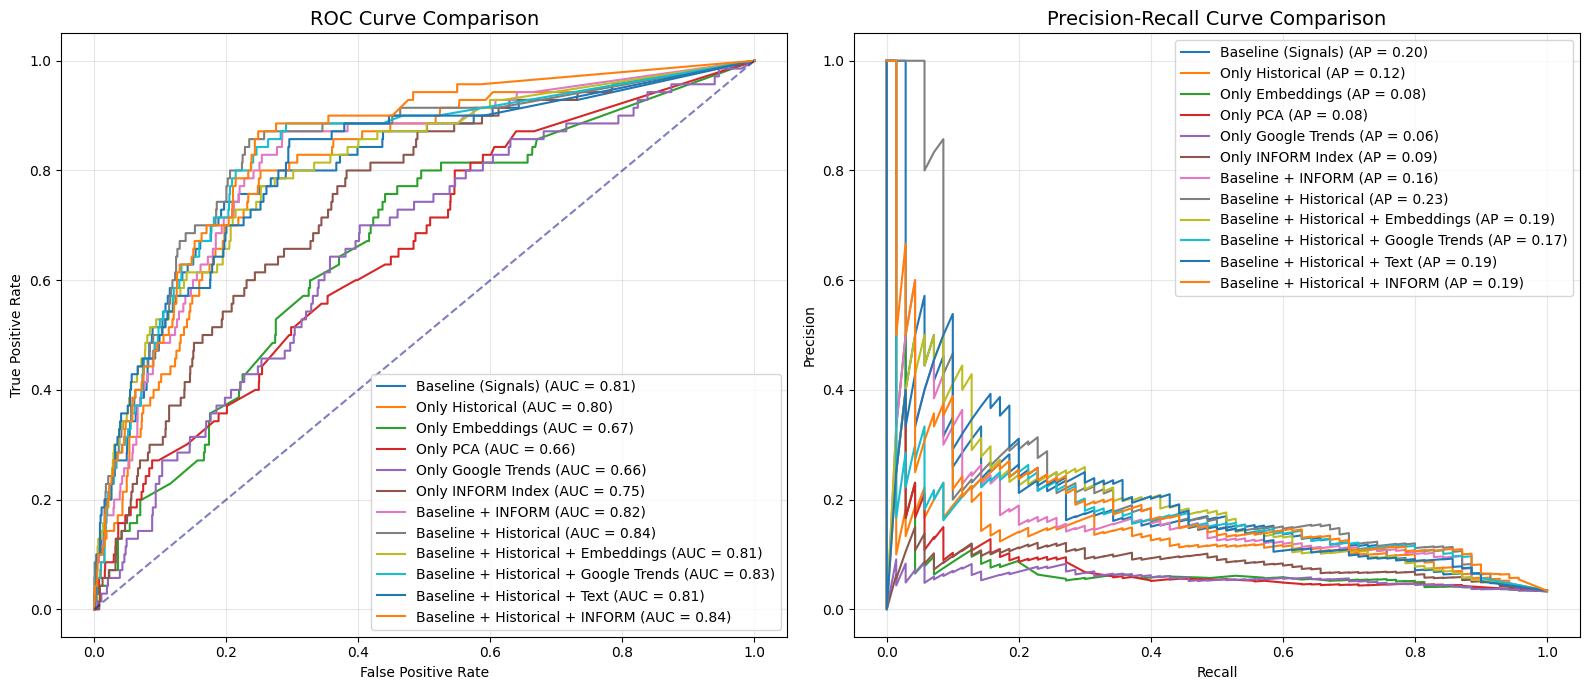

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, roc_auc_score, average_precision_score,
    classification_report, roc_curve, precision_recall_curve
)

# 1. DEFINE EXPERIMENT SETS
experiments = {
    # --- SOLO GROUPS ---
    "Baseline (Signals)": features_signals,
    "Only Historical": best_historical,
    "Only Embeddings": best_emb + best_emb_mean,
    "Only PCA": best_pca + best_pca_mean, 
    "Only Google Trends": best_google,
    "Only INFORM Index": best_inform,
    
    # --- COMBINED GROUPS ---
    "Baseline + INFORM": features_signals + best_inform,
    "Baseline + Historical": best_historical + features_signals,
    "Baseline + Historical + Embeddings": best_historical + features_signals + best_emb + best_emb_mean + best_pca + best_pca_mean,
    "Baseline + Historical + Google Trends": best_historical + features_signals + best_google,
    "Baseline + Historical + Text": best_historical + features_signals + best_emb + best_emb_mean + best_pca + best_pca_mean + best_google,
    "Baseline + Historical + INFORM": best_historical + features_signals + best_inform
}

# Containers for results
comparison_results = []

# Prepare the plot layout
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(16, 7))

for name, f_list in experiments.items():
    print(f"\n" + "="*60)
    print(f"RUNNING EXPERIMENT: {name}")
    print(f"Features count: {len(f_list)}")
    print("="*60)
    
    # 2. PREPARE DATA
    X, y = prepare_ml_experiment(df, features_to_use=f_list)
    periods = X.index.get_level_values('month')

    # 3. DEFINE SPLIT STRATEGY
    panel_split = PanelSplit(
        periods=periods,
        n_splits=24,   
        test_size=1,
        gap=1          
    )

    # 4. INITIALIZE MODEL
    rf_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    all_y_true, all_y_prob = [], []

    # 5. CROSS-VALIDATION LOOP (Moving Window)
    for train_idx, test_idx in panel_split.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        rf_model.fit(X_train, y_train)
        
        probs = rf_model.predict_proba(X_test)[:, 1]
        
        all_y_true.extend(y_test.values)
        all_y_prob.extend(probs)

    # Convert arrays to numpy arrays for vector math operations
    all_y_true = np.array(all_y_true)
    all_y_prob = np.array(all_y_prob)

    # 6. OPTIMIZE THRESHOLD VIA PRECISION-RECALL CURVE
    precision, recall, thresholds = precision_recall_curve(all_y_true, all_y_prob)
    
    # Calculate F1-score safely for every possible threshold
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    
    # Find the threshold index that yields the maximum F1-Score
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    best_f1 = f1_scores[best_idx]
    
    # Generate optimized predictions based on the custom threshold
    all_y_pred = (all_y_prob >= best_threshold).astype(int)

    # Global metrics
    roc_auc = roc_auc_score(all_y_true, all_y_prob)
    avg_prec = average_precision_score(all_y_true, all_y_prob)
    
    # Append results including the chosen optimal threshold
    comparison_results.append({
        'Experiment': name,
        'Best Threshold': best_threshold,
        'F1-Score': best_f1,
        'AUC-ROC': roc_auc,
        'Avg Precision': avg_prec,
        'Features': len(f_list)
    })

    # 7. PRINT ANALYSIS
    print(f"\n--- TOP 10 PREDICTORS ({name}) ---")
    importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
    print(importances.head(10))
    
    print(f"\nClassification Report ({name}) [Optimized Threshold = {best_threshold:.4f}]:")
    print(classification_report(all_y_true, all_y_pred))

    # 8. ADD TO PLOTS
    # ROC Curve
    fpr, tpr, _ = roc_curve(all_y_true, all_y_prob)
    ax_roc.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
    
    # PR Curve
    ax_pr.plot(recall, precision, label=f'{name} (AP = {avg_prec:.2f})')

# --- FINAL COMPARISON TABLE ---
# Sorted by the newly found optimal F1-Score
df_results = pd.DataFrame(comparison_results).sort_values(by='F1-Score', ascending=False)
print("\n" + "#"*40)
print("       FINAL RANKING (OPTIMIZED)")
print("#"*40)
print(df_results.to_string(index=False))

# --- VISUALIZATION FINISHING TOUCHES ---
ax_roc.plot([0, 1], [0, 1], color='navy', linestyle='--', alpha=0.5)
ax_roc.set_title('ROC Curve Comparison', fontsize=14)
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.legend(loc='lower right')
ax_roc.grid(alpha=0.3)

ax_pr.set_title('Precision-Recall Curve Comparison', fontsize=14)
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.legend(loc='upper right')
ax_pr.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Let's now do it only for the main models so that the graphins are more interpretable:


RUNNING EXPERIMENT: Baseline (Signals)
Features count: 19

--- TOP 10 PREDICTORS (Baseline (Signals)) ---
disp_6m_avg                 0.215062
rolling_3m_displacements    0.164006
risk                        0.139029
monthly_displacement        0.105535
fat_6m_avg                  0.088044
events                      0.058329
fatalities                  0.049440
risk_gt_06                  0.045723
is_protracted               0.038421
p_sig2                      0.024723
dtype: float64

Classification Report (Baseline (Signals)) [Optimized Threshold = 0.2772]:
              precision    recall  f1-score   support

         0.0       0.98      0.91      0.95      1994
         1.0       0.17      0.51      0.26        70

    accuracy                           0.90      2064
   macro avg       0.58      0.71      0.60      2064
weighted avg       0.95      0.90      0.92      2064


RUNNING EXPERIMENT: Baseline + Historical
Features count: 34

--- TOP 10 PREDICTORS (Baseline + Historic

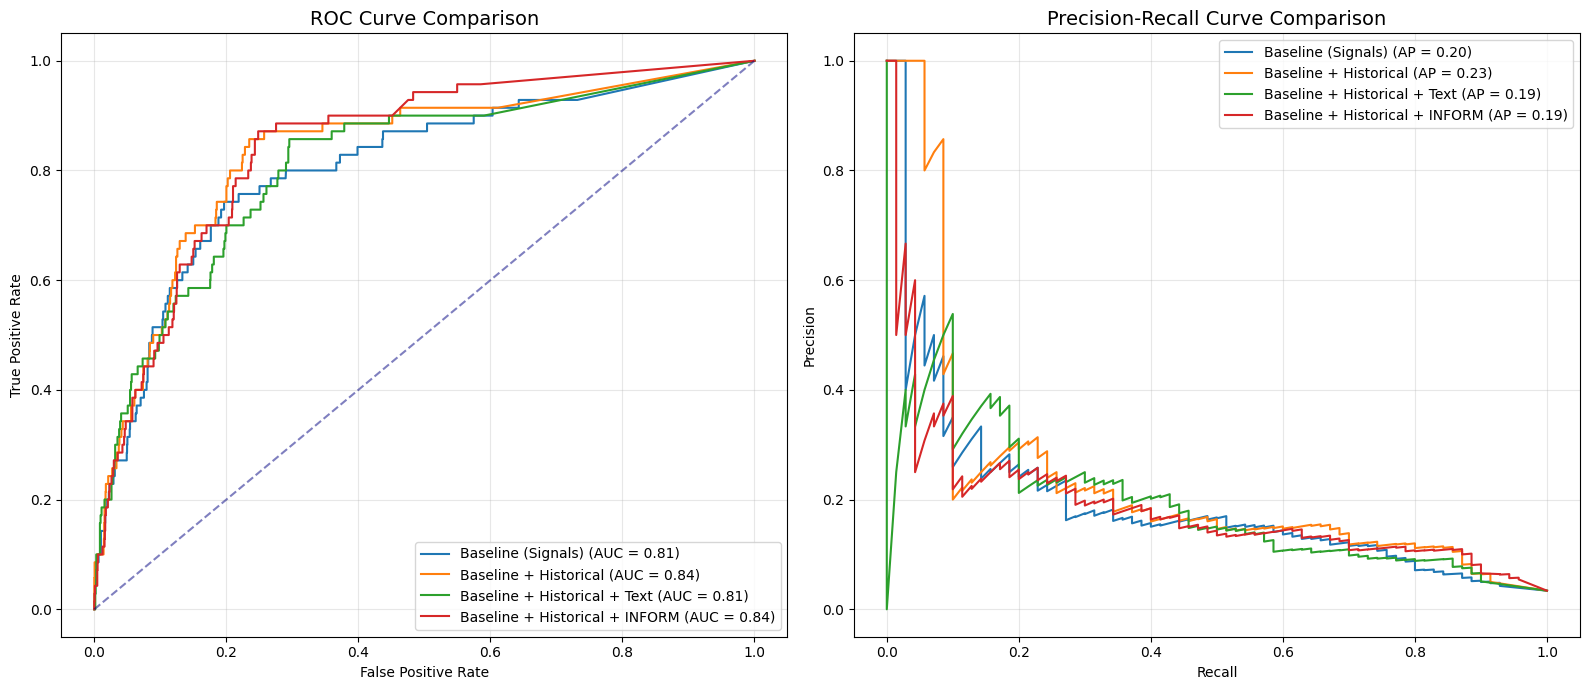

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, roc_auc_score, average_precision_score,
    classification_report, roc_curve, precision_recall_curve
)

# 1. DEFINE EXPERIMENT SETS
experiments = {
    # --- SOLO GROUPS ---
    "Baseline (Signals)": features_signals,
    
    # --- COMBINED GROUPS ---
    "Baseline + Historical": best_historical + features_signals,
    "Baseline + Historical + Text": best_historical + features_signals + best_emb + best_emb_mean + best_pca + best_pca_mean + best_google,
    "Baseline + Historical + INFORM": best_historical + features_signals + best_inform
}

# Containers for results
comparison_results = []

# Prepare the plot layout
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(16, 7))

for name, f_list in experiments.items():
    print(f"\n" + "="*60)
    print(f"RUNNING EXPERIMENT: {name}")
    print(f"Features count: {len(f_list)}")
    print("="*60)
    
    # 2. PREPARE DATA
    X, y = prepare_ml_experiment(df, features_to_use=f_list)
    periods = X.index.get_level_values('month')

    # 3. DEFINE SPLIT STRATEGY
    panel_split = PanelSplit(
        periods=periods,
        n_splits=24,   
        test_size=1,
        gap=1          
    )

    # 4. INITIALIZE MODEL
    rf_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    all_y_true, all_y_prob = [], []

    # 5. CROSS-VALIDATION LOOP (Moving Window)
    for train_idx, test_idx in panel_split.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        rf_model.fit(X_train, y_train)
        
        probs = rf_model.predict_proba(X_test)[:, 1]
        
        all_y_true.extend(y_test.values)
        all_y_prob.extend(probs)

    # Convert arrays to numpy arrays for vector math operations
    all_y_true = np.array(all_y_true)
    all_y_prob = np.array(all_y_prob)

    # 6. OPTIMIZE THRESHOLD VIA PRECISION-RECALL CURVE
    precision, recall, thresholds = precision_recall_curve(all_y_true, all_y_prob)
    
    # Calculate F1-score safely for every possible threshold
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    
    # Find the threshold index that yields the maximum F1-Score
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    best_f1 = f1_scores[best_idx]
    
    # Generate optimized predictions based on the custom threshold
    all_y_pred = (all_y_prob >= best_threshold).astype(int)

    # Global metrics
    roc_auc = roc_auc_score(all_y_true, all_y_prob)
    avg_prec = average_precision_score(all_y_true, all_y_prob)
    
    # Append results including the chosen optimal threshold
    comparison_results.append({
        'Experiment': name,
        'Best Threshold': best_threshold,
        'F1-Score': best_f1,
        'AUC-ROC': roc_auc,
        'Avg Precision': avg_prec,
        'Features': len(f_list)
    })

    # 7. PRINT ANALYSIS
    print(f"\n--- TOP 10 PREDICTORS ({name}) ---")
    importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
    print(importances.head(10))
    
    print(f"\nClassification Report ({name}) [Optimized Threshold = {best_threshold:.4f}]:")
    print(classification_report(all_y_true, all_y_pred))

    # 8. ADD TO PLOTS
    # ROC Curve
    fpr, tpr, _ = roc_curve(all_y_true, all_y_prob)
    ax_roc.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
    
    # PR Curve
    ax_pr.plot(recall, precision, label=f'{name} (AP = {avg_prec:.2f})')

# --- FINAL COMPARISON TABLE ---
# Sorted by the newly found optimal F1-Score
df_results = pd.DataFrame(comparison_results).sort_values(by='F1-Score', ascending=False)
print("\n" + "#"*40)
print("       FINAL RANKING (OPTIMIZED)")
print("#"*40)
print(df_results.to_string(index=False))

# --- VISUALIZATION FINISHING TOUCHES ---
ax_roc.plot([0, 1], [0, 1], color='navy', linestyle='--', alpha=0.5)
ax_roc.set_title('ROC Curve Comparison', fontsize=14)
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.legend(loc='lower right')
ax_roc.grid(alpha=0.3)

ax_pr.set_title('Precision-Recall Curve Comparison', fontsize=14)
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.legend(loc='upper right')
ax_pr.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Now we define the PanelSplit, that will allow us to split the data in train and test without data leakage.

In [79]:
periods = X.index.get_level_values('month')

# Horizon = 2 months ahead, then gap = 1.
panel_split = PanelSplit(
    periods=periods,
    n_splits=24,   
    test_size=1,
    gap=1          
)

Now we define the model that we are using, that is a RandomForestClassifier.

In [80]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

Next we apply CROSS_VAL_FIT_PREDICT to do the predictions

In [81]:
# To store actual values and predictions only for the test periods
all_y_true = []
all_y_pred = []
all_y_prob = []

# Iterating through the splits (Moving Window)
for train_idx, test_idx in panel_split.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Train the model
    rf_model.fit(X_train, y_train)
    
    # Predict probabilities and classes
    probs = rf_model.predict_proba(X_test)[:, 1]
    preds = rf_model.predict(X_test)
    
    # Store results
    all_y_true.extend(y_test.values)
    all_y_pred.extend(preds)
    all_y_prob.extend(probs)

# Print features importance
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\n--- TOP 10 PREDICTORS ---")
print(importances.head(15))


--- TOP 10 PREDICTORS ---
disp_6m_avg                  0.179042
rolling_3m_displacements     0.088133
logfat_risk                  0.083931
monthly_displacement         0.075851
risk_lag1                    0.072997
any_violence_risk            0.070064
risk                         0.067234
fat_6m_avg                   0.047915
monthly_displacement_lag1    0.036096
fatalities_lag1              0.029698
events_lag1                  0.028360
population_5km               0.027719
fatalities                   0.026954
events                       0.025253
monthly_displacement_lag2    0.024419
dtype: float64


Finally we plot the ROC curve and the Precision-Recall curve of our predictions.

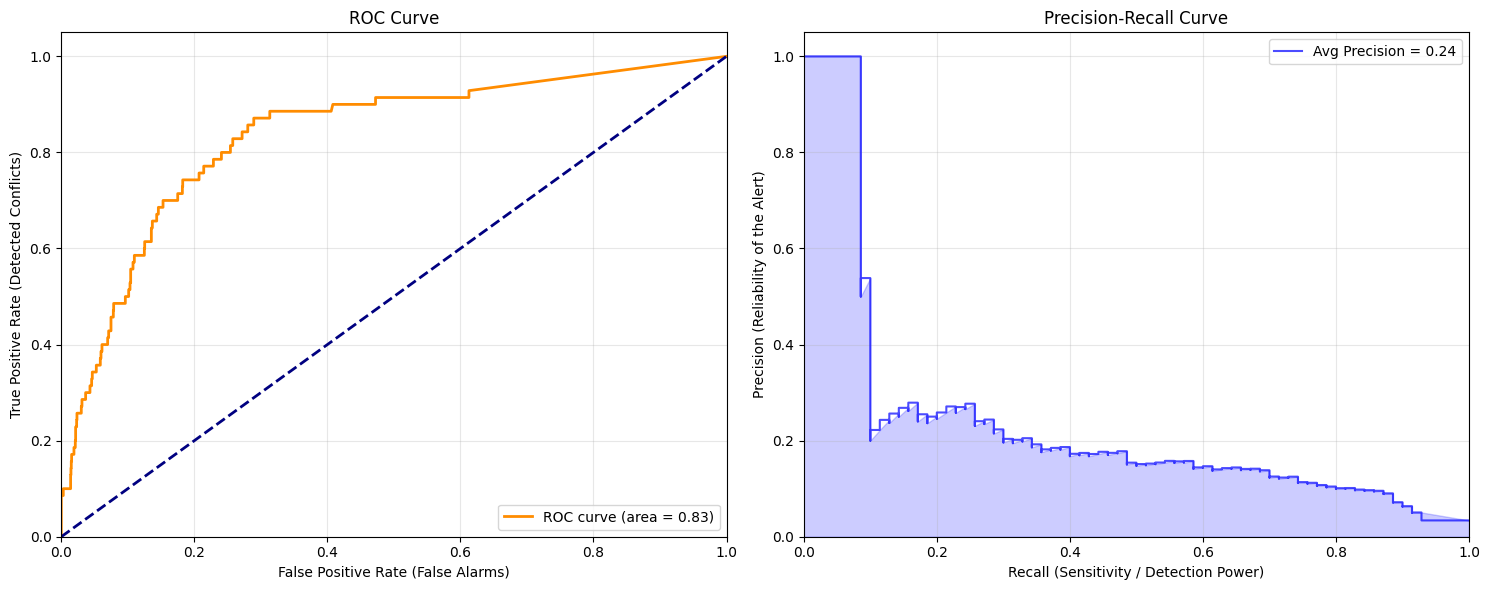

In [82]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- Plot 1: ROC Curve ---
fpr, tpr, _ = roc_curve(all_y_true, all_y_prob)
roc_auc = auc(fpr, tpr)

ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate (False Alarms)')
ax1.set_ylabel('True Positive Rate (Detected Conflicts)')
ax1.set_title('ROC Curve')
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

# --- Plot 2: Precision-Recall Curve ---
# This is the most important plot for imbalanced data!
precision, recall, _ = precision_recall_curve(all_y_true, all_y_prob)
avg_precision = average_precision_score(all_y_true, all_y_prob)

ax2.step(recall, precision, color='b', alpha=0.7, where='post', label=f'Avg Precision = {avg_precision:.2f}')
ax2.fill_between(recall, precision, alpha=0.2, color='b')
ax2.set_xlabel('Recall (Sensitivity / Detection Power)')
ax2.set_ylabel('Precision (Reliability of the Alert)')
ax2.set_ylim([0.0, 1.05])
ax2.set_xlim([0.0, 1.0])
ax2.set_title('Precision-Recall Curve')
ax2.legend(loc="upper right")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()